In [ ]:
import numpy as np
import tensorflow as tf
import keras
import matplotlib.pyplot as plt
import os
import cv2

In [ ]:
import pandas as pd
dataset1=pd.read_csv('kx.csv')
dataset2=pd.read_csv('keystroke_datax2.csv')
dataset1['Label'] = 0
dataset2['Label'] = 1

In [ ]:
combined = pd.concat([dataset1, dataset2], ignore_index=True)
combined

,Key,HoldTime,FlightTime,DigraphLatency,Label
0,a,0.1441,0.0000,0.1527,0
1,r,0.0660,0.0771,0.1553,0
2,e,0.0877,0.2156,0.1938,0
3,e,0.0853,0.1584,0.1608,0
4,n,0.0781,0.1017,0.1090,0
...,...,...,...,...,...
12704,c,0.1288,0.6540,0.6130,1
12705,i,0.0998,0.1602,0.1892,1
12706,t,0.1296,0.2238,0.1940,1
12707,y,0.0829,0.1778,0.2245,1


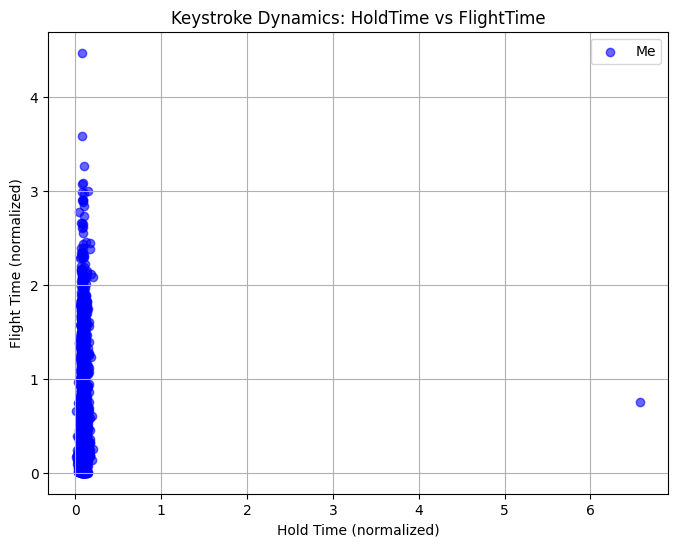

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(dataset1['HoldTime'], dataset1['FlightTime'], label='Me', alpha=0.6, c='blue')


plt.title('Keystroke Dynamics: HoldTime vs FlightTime')
plt.xlabel('Hold Time (normalized)')
plt.ylabel('Flight Time (normalized)')
plt.legend()
plt.grid(True)
plt.show()

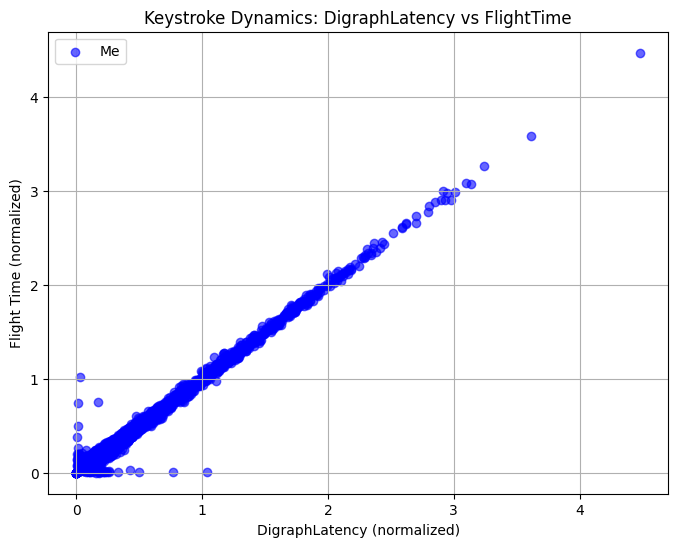

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(dataset1['DigraphLatency'], dataset1['FlightTime'], label='Me', alpha=0.6, c='blue')


plt.title('Keystroke Dynamics: DigraphLatency vs FlightTime')
plt.xlabel('DigraphLatency (normalized)')
plt.ylabel('Flight Time (normalized)')
plt.legend()
plt.grid(True)
plt.show()

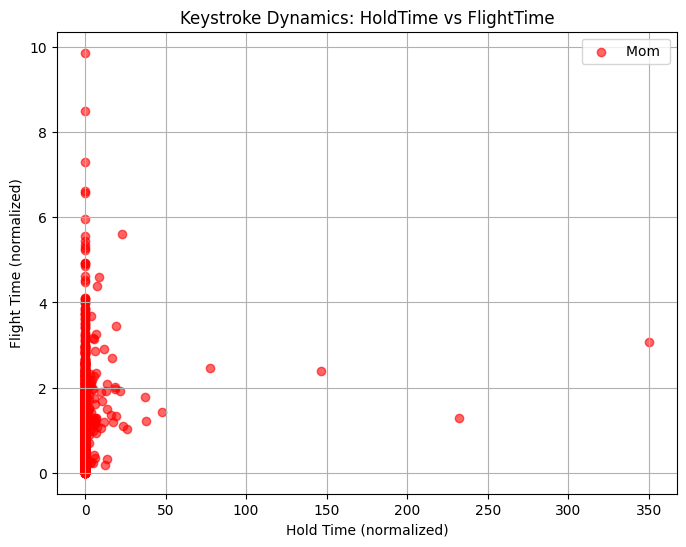

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(dataset2['HoldTime'], dataset2['FlightTime'], label='Mom ', alpha=0.6, c='red')

plt.title('Keystroke Dynamics: HoldTime vs FlightTime')
plt.xlabel('Hold Time (normalized)')
plt.ylabel('Flight Time (normalized)')
plt.legend()
plt.grid(True)
plt.show()

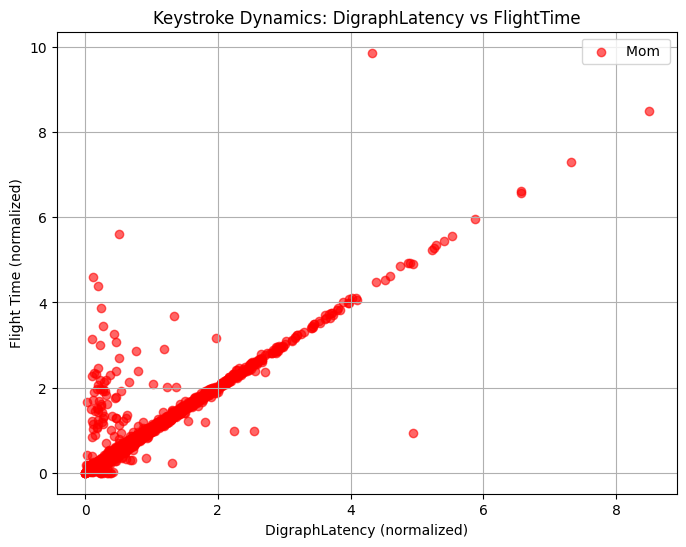

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(dataset2['DigraphLatency'], dataset2['FlightTime'], label='Mom ', alpha=0.6, c='red')

plt.title('Keystroke Dynamics: DigraphLatency vs FlightTime')
plt.xlabel('DigraphLatency (normalized)')
plt.ylabel('Flight Time (normalized)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
sc1 = StandardScaler()
sc2 = StandardScaler()
ds1_scaled = dataset1.copy()
ds1_scaled.iloc[:, 1:] = sc1.fit_transform(dataset1.iloc[:, 1:])
ds2_scaled = dataset2.copy()
ds2_scaled.iloc[:, 1:4] = sc2.fit_transform(dataset2.iloc[:, 1:4])


In [ ]:
ds1_scaled

,Key,HoldTime,FlightTime,DigraphLatency,Label
0,a,0.750244,-0.887609,-0.474527,0
1,r,-0.262023,-0.678488,-0.467458,0
2,e,0.019234,-0.302831,-0.362789,0
3,e,-0.011872,-0.457976,-0.452506,0
4,n,-0.105193,-0.611765,-0.593333,0
...,...,...,...,...,...
7658,y,-0.409780,1.281168,1.285545,0
7659,u,-0.150557,-0.319647,-0.374751,0
7660,r,0.334191,-0.257264,-0.359255,0
7661,i,-0.464217,-0.723784,-0.557718,0


In [ ]:
ds2_scaled

,Key,HoldTime,FlightTime,DigraphLatency,Label
0,n,-0.047491,-0.800177,-0.310630,1
1,2,-0.042488,1.476724,1.569424,1
2,0,-0.045992,-0.414599,-0.375221,1
3,0,-0.047721,-0.517868,-0.504246,1
4,1,-0.047736,-0.527522,-0.532219,1
...,...,...,...,...,...
5041,c,-0.042289,0.156455,0.138050,1
5042,i,-0.046726,-0.565846,-0.527976,1
5043,t,-0.042167,-0.472816,-0.520433,1
5044,y,-0.049312,-0.540102,-0.472500,1


In [ ]:
ds1_scaled = ds1_scaled.drop('Key', axis=1)
ds2_scaled = ds2_scaled.drop('Key', axis=1)

In [ ]:
ds_combined = pd.concat([ds1_scaled, ds2_scaled], ignore_index=True)

In [ ]:
from sklearn.utils import shuffle
ds_combined = shuffle(ds_combined)
ds_combined

,HoldTime,FlightTime,DigraphLatency,Label
8924,-0.049649,-0.351409,-0.329960,1
10453,-0.047491,-0.539517,-0.526248,1
8980,-0.048073,-0.463601,-0.448455,1
10087,-0.046650,-0.084020,-0.037179,1
43,-0.101305,0.226887,0.306549,0
...,...,...,...,...
12295,-0.042289,-0.588080,-0.572294,1
660,0.384739,-0.304458,-0.428038,0
10438,-0.050842,-0.583253,-0.586438,1
7085,0.199395,0.957859,0.991112,0


In [ ]:
X = ds_combined.iloc[:,:-1].values
y = ds_combined.iloc[:,-1].values

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [ ]:
model = Sequential()
model.add(Dense(16, input_shape=(3,), activation='relu'))   # input layer
model.add(Dropout(0.2))                                     # regularization
model.add(Dense(8, activation='relu'))                      # hidden layer
model.add(Dense(1, activation='sigmoid'))                   # output layer (binary classification)

model.compile(optimizer=Adam(0.001), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209 (836.00 B)

 Trainable params: 209 (836.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2)


Epoch 1/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5946 - loss: 0.6750 - val_accuracy: 0.6032 - val_loss: 0.6546
Epoch 2/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6198 - loss: 0.6475 - val_accuracy: 0.5978 - val_loss: 0.6020
Epoch 3/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6026 - loss: 0.5981 - val_accuracy: 0.8132 - val_loss: 0.5194
Epoch 4/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7564 - loss: 0.5123 - val_accuracy: 0.9189 - val_loss: 0.4258
Epoch 5/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8632 - loss: 0.4456 - val_accuracy: 0.9267 - val_loss: 0.3505
Epoch 6/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8910 - loss: 0.3706 - val_accuracy: 0.9277 - val_loss: 0.2877
Epoch 7/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8996 - loss: 0.3225 - val_accuracy: 0.9317 - val_loss: 0.2459
Epoch 8/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9152 - loss: 0.2790 - val_accu

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype("int32").flatten()
print("Classification Report:\n")
print(classification_report(y_test, y_pred, digits=4))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("Accuracy:", accuracy_score(y_test, y_pred))


80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Classification Report:

              precision    recall  f1-score   support

           0     0.9907    0.9719    0.9812      1532
           1     0.9586    0.9861    0.9722      1010

    accuracy                         0.9776      2542
   macro avg     0.9746    0.9790    0.9767      2542
weighted avg     0.9779    0.9776    0.9776      2542

Confusion Matrix:
[[1489   43]
 [  14  996]]
Accuracy: 0.9775767112509834


In [ ]:
import joblib
joblib.dump(model, 'model.pkl')
joblib.dump(sc, 'scaler.pkl')

print(" Model and scaler saved successfully.")

# **This is the new model after scaling both datasets together**

In [ ]:
df1 = pd.read_csv('kx.csv')
df2 = pd.read_csv('keystroke_datax2.csv')
df1['Label'] = 0
df2['Label'] = 1

In [ ]:
df = pd.concat([df1, df2], axis=0)
df

,Key,HoldTime,FlightTime,DigraphLatency,Label
0,a,0.1441,0.0000,0.1527,0
1,r,0.0660,0.0771,0.1553,0
2,e,0.0877,0.2156,0.1938,0
3,e,0.0853,0.1584,0.1608,0
4,n,0.0781,0.1017,0.1090,0
...,...,...,...,...,...
5041,c,0.1288,0.6540,0.6130,1
5042,i,0.0998,0.1602,0.1892,1
5043,t,0.1296,0.2238,0.1940,1
5044,y,0.0829,0.1778,0.2245,1


In [ ]:
import numpy as np
df[['HoldTime', 'FlightTime', 'DigraphLatency']] = np.log1p(df[['HoldTime', 'FlightTime', 'DigraphLatency']])
df

,Key,HoldTime,FlightTime,DigraphLatency,Label
0,a,0.134618,0.000000,0.142107,0
1,r,0.063913,0.074272,0.144360,0
2,e,0.084065,0.195238,0.177141,0
3,e,0.081856,0.147040,0.149109,0
4,n,0.075200,0.096854,0.103459,0
...,...,...,...,...,...
5041,c,0.121155,0.503197,0.478096,1
5042,i,0.095128,0.148592,0.173281,1
5043,t,0.121864,0.201961,0.177309,1
5044,y,0.079643,0.163648,0.202533,1


In [ ]:
sc = StandardScaler()
df_scaled = sc.fit_transform(df.iloc[:,1:4])
df_scaled = pd.DataFrame(df_scaled, columns=df.columns[1:4])
df_scaled['Label'] = df['Label'].values
df_scaled

,HoldTime,FlightTime,DigraphLatency,Label
0,0.164655,-1.147881,-0.622250,0
1,-0.216954,-0.867304,-0.613420,0
2,-0.108189,-0.410334,-0.484946,0
3,-0.120111,-0.592411,-0.594807,0
4,-0.156036,-0.781996,-0.773718,0
...,...,...,...,...
12704,0.091991,0.753037,0.694532,1
12705,-0.048480,-0.586546,-0.500076,1
12706,0.095815,-0.384937,-0.484289,1
12707,-0.132060,-0.529670,-0.385435,1


In [ ]:
from sklearn.utils import shuffle
df_scaled = shuffle(df_scaled)

In [ ]:
X2 = df_scaled.iloc[:,:-1].values
y2 = df_scaled.iloc[:,-1].values

In [ ]:
from sklearn.model_selection import train_test_split
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size = 0.2, random_state = 0)

In [ ]:
model2 = Sequential()
model2.add(Dense(32, input_shape=(3,), activation='relu'))
model2.add(Dropout(0.3))
model2.add(Dense(16, activation='relu'))
model2.add(Dense(1, activation='sigmoid'))

model2.compile(optimizer=Adam(0.001), loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
model2.fit(X2_train, y2_train, epochs=50, batch_size=32, validation_split=0.25)

Epoch 1/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7975 - loss: 0.4201 - val_accuracy: 0.8096 - val_loss: 0.4323
Epoch 2/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8054 - loss: 0.4176 - val_accuracy: 0.8108 - val_loss: 0.4332
Epoch 3/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7977 - loss: 0.4206 - val_accuracy: 0.8092 - val_loss: 0.4344
Epoch 4/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8164 - loss: 0.3988 - val_accuracy: 0.8084 - val_loss: 0.4341
Epoch 5/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7942 - loss: 0.4281 - val_accuracy: 0.8084 - val_loss: 0.4329
Epoch 6/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8008 - loss: 0.4132 - val_accuracy: 0.8053 - val_loss: 0.4335
Epoch 7/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8059 - loss: 0.4112 - val_accuracy: 0.8092 - val_loss: 0.4343
Epoch 8/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8021 - loss: 0.4197 - val_accuracy: 0.

<Axes: xlabel='FlightTime', ylabel='Count'>

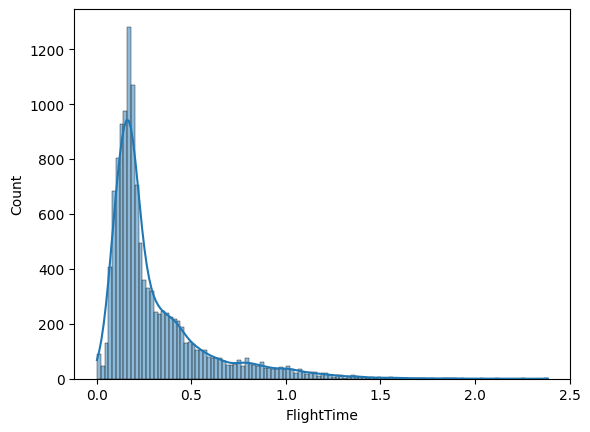

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['FlightTime'], kde=True)
# sns.histplot(df['HoldTime'], kde=True)
# sns.histplot(df['DigraphLatency'], kde=True)

<Axes: xlabel='DigraphLatency', ylabel='Count'>

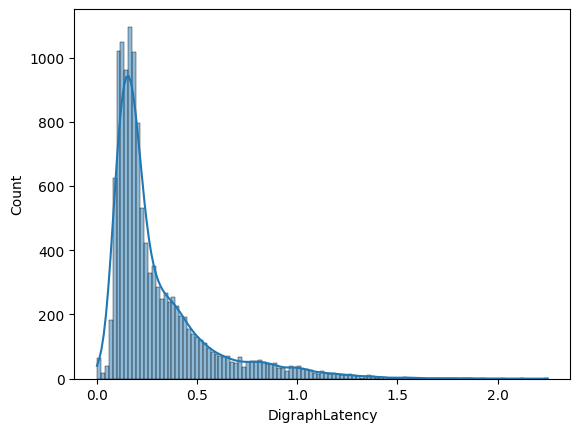

In [ ]:
sns.histplot(df['DigraphLatency'], kde=True)

In [ ]:
# import numpy as np
# df[['HoldTime', 'FlightTime', 'DigraphLatency']] = np.log1p(df[['HoldTime', 'FlightTime', 'DigraphLatency']])


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
y2_pred_prob = model2.predict(X2_test)
y2_pred = (y2_pred_prob > 0.5).astype("int32").flatten()

# Confusion matrix
cm2 = confusion_matrix(y2_test, y2_pred)
print("Confusion Matrix:\n", cm2)

# Deta


80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Confusion Matrix:
 [[1352  170]
 [ 353  667]]


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X2_train, y2_train)

y2_pred = rf_model.predict(X2_test)

print("Confusion Matrix:\n", confusion_matrix(y2_test, y2_pred))
print("\nClassification Report:\n", classification_report(y2_test, y2_pred))
print("Accuracy:", accuracy_score(y2_test, y2_pred))

Confusion Matrix:
 [[1260  262]
 [ 315  705]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.83      0.81      1522
           1       0.73      0.69      0.71      1020

    accuracy                           0.77      2542
   macro avg       0.76      0.76      0.76      2542
weighted avg       0.77      0.77      0.77      2542

Accuracy: 0.7730133752950433


In [ ]:
model2.save("model2.keras")

In [ ]:
from google.colab import files
files.download("model2.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pickle
with open("scaler.pkl", "wb") as f:
    pickle.dump(sc, f)
    files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
model2.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,021 (7.90 KB)

 Trainable params: 673 (2.63 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,348 (5.27 KB)